In [1]:
import numpy as np
import pandas as pd
from matplotlib import pylab as plt
metadata_file = '/Users/fmcc0003/issm/projects/ISMIP6Hackathon/GroupTFtoOcean/data_analysis/Metadata_icefront.txt'
df_info = pd.read_csv(metadata_file)

computed_name = 'ComputedScalarsHelene'
mnt_pth = '/Volumes/FMac/computing/data/antarctica/' #mount path
pth_ismip6hack= mnt_pth + 'ismip6/hackathon/ComputedScalars/' #write folder
pth_ismip6 =mnt_pth + 'ismip6/hackathon/' #read folder
pth_helene =mnt_pth + 'ismip6/hackathon/ComputedScalarsHelene/'
pth_table = '/Users/fmcc0003/issm/projects/ISMIP6Hackathon/GroupBMBtodSLR/data_analysis/tables/'

### Get all the data

In [2]:
colors = ['#1f77b4','#2ca02c','#9467bd']
colors2 = ['darksalmon','coral','olive']
scatters = ['.','+','^','v']

df_dils_prmse = pd.read_csv('tables/prmse_recalc_linear_dynamic_ice_loss_sensitivity_from_cumBMB_tmin2150.csv')
df_dils = pd.read_csv(f'{pth_table}linear_dynamic_ice_loss_sensitivity_from_cumBMB_tmin2150.csv')
#df_dils_2200 = pd.read_csv(f'{pth_table}linear_dynamic_ice_loss_sensitivity_from_cumBMB_tmin2200.csv')
#df_dils = pd.read_csv(f'{pth_table}linear_dynamic_ice_loss_sensitivity_from_cumBMB.csv')

regions = df_dils.columns[4:].values.tolist()
regions = ['AIS', 'Amundsen', 'Ross', 'FilchnerRonne', 'Aurora', 'Wilkes']
regions_all= regions.copy()
regions1 = regions[1:]
regions_all1=regions1.copy()

experiments = np.unique(df_dils["Experiment"])
df_exp = df_dils[df_dils['Experiment']== experiments[0]].reset_index(drop=True)
models = df_exp.Model.values

df_best = df_exp.copy()
df_best['mean-error']=1e15
df_best = df_best.drop(df_best.columns[0:2],axis=1)
#df_best = df_best.drop(df_best.columns[1],axis=1)
df_best = df_best.drop(df_best.columns[1:11],axis=1)
for region in regions:
    df_best[f'dils_{region}']=0
    df_best[f'dils_std_{region}']=0
    df_best[f'dils_min_{region}']=0
    df_best[f'dils_max_{region}']=0
    df_best['parameterization']=''
    df_best['calving']=''
    df_best['initialisation']=''
    df_best['resolution']=''
    df_best['shelfarea']=''

renamer = {}
renamer['DOE_MALI_4km']='DOE_MALI_1'
renamer['DOE_MALI_8km_Ant95']='DOE_MALI_2'
renamer['DOE_MALI_8km_AntMean']='DOE_MALI_3' 

In [3]:
# initialisation
initialisation={'DC_ISSM':'DA', 'DOE_MALI_4km':'DA+', 'DOE_MALI_8km_Ant95':'DA+', 'DOE_MALI_8km_AntMean':'DA+',\
                'IGE_ElmerIce':'DA', 'ILTS_SICOPOLIS':'SP+', 'IMAU_UFEMISM1':'SP+', 'IMAU_UFEMISM2':'SP+', \
                'IMAU_UFEMISM3':'SP+', 'IMAU_UFEMISM4':'SP+', 'LSCE_GRISLI2':'SP+', 'LSCE_GRISLI':'SP+', \
                'NCAR_CISM1':'SP+', 'NCAR_CISM2':'SP+', 'NORCE_CISM3-MAR364-ERA-t1-nonlocal':'SP+', \
                'NORCE_CISM4-MAR364-ERA-t1-nonlocal':'SP+', 'NORCE_CISM5-MAR364-ERA-t1-nonlocal':'SP+', \
                'NORCE_CISM3-MAR364-ERA-t1-local':'SP+', 'NORCE_CISM4-MAR364-ERA-t1-local':'SP+', \
                'NORCE_CISM5-MAR364-ERA-t1-local':'SP+', 'NORCE_CISM2-MAR364-ERA-t1':'SP+', \
                'NORCE_CISM3-MAR364-ERA-t1':'SP+', 'NORCE_CISM4-MAR364-ERA-t1':'SP+', 'NORCE_CISM4-MAR364-JRA-t1':'SP+', \
                'NORCE_CISM5-MAR364-ERA-t1':'SP+', 'PIK_PISM':'SP', 'UCM_Yelmo':'SP+', 'UCSD_ISSM':'DA', \
                'ULB_fETISh-KoriBU1':'DA*', 'ULB_fETISh-KoriBU2':'DA*', 'UNN_Ua':'DA', 'UTAS_ElmerIce':'DA',\
                'VUB_AISMPALEO':'SP', 'VUW_PISM1':'SP', 'VUW_PISM1_s1':'SP', 'VUW_PISM1_s2':'SP', 'VUW_PISM1_s3':'SP',\
                'VUW_PISM1_s4':'SP','VUW_PISM2':'SP', 'VUW_PISM2_s1':'SP', 'VUW_PISM2_s2':'SP', 'VUW_PISM2_s3':'SP', 'VUW_PISM2_s4':'SP'}

for i,Mod in enumerate(df_best['Model']):
    df_best['initialisation'][i]=initialisation[Mod]

/var/folders/v3/r3qsjbkx2gl_9r5s_n0726wxcg0fz6/T/ipykernel_58652/882623642.py:16: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_best['initialisation'][i]=initialisation[Mod]
/var/folders/v3/r3qsjbkx2gl_9r5s_n0726wxcg0fz6/T/ipykernel_58652

In [4]:
# calving group
calving_group={'DC_ISSM':2, 'DOE_MALI_4km':2, 'DOE_MALI_8km_Ant95':2, 'DOE_MALI_8km_AntMean':2,\
                'IGE_ElmerIce':2, 'ILTS_SICOPOLIS':2, 'IMAU_UFEMISM1':2, 'IMAU_UFEMISM2':2, \
                'IMAU_UFEMISM3':2, 'IMAU_UFEMISM4':2, 'LSCE_GRISLI2':1, 'LSCE_GRISLI':1, \
                'NCAR_CISM1':2, 'NCAR_CISM2':2, 'NORCE_CISM3-MAR364-ERA-t1-nonlocal':2, \
                'NORCE_CISM4-MAR364-ERA-t1-nonlocal':2, 'NORCE_CISM5-MAR364-ERA-t1-nonlocal':2, \
                'NORCE_CISM3-MAR364-ERA-t1-local':2, 'NORCE_CISM4-MAR364-ERA-t1-local':2, \
                'NORCE_CISM5-MAR364-ERA-t1-local':2, 'NORCE_CISM2-MAR364-ERA-t1':2, \
                'NORCE_CISM3-MAR364-ERA-t1':2, 'NORCE_CISM4-MAR364-ERA-t1':2, 'NORCE_CISM4-MAR364-JRA-t1':2, \
                'NORCE_CISM5-MAR364-ERA-t1':2, 'PIK_PISM':1, 'UCM_Yelmo':1, 'UCSD_ISSM':3, \
                'ULB_fETISh-KoriBU1':3, 'ULB_fETISh-KoriBU2':2, 'UNN_Ua':2, 'UTAS_ElmerIce':2,\
                'VUB_AISMPALEO':2, 'VUW_PISM1':1, 'VUW_PISM1_s1':1, 'VUW_PISM1_s2':1, 'VUW_PISM1_s3':1,\
                'VUW_PISM1_s4':1,'VUW_PISM2':1, 'VUW_PISM2_s1':1, 'VUW_PISM2_s2':1, 'VUW_PISM2_s3':1, 'VUW_PISM2_s4':1}

for i,Mod in enumerate(df_best['Model']):
    df_best['calving'][i]=calving_group[Mod]

/var/folders/v3/r3qsjbkx2gl_9r5s_n0726wxcg0fz6/T/ipykernel_58652/922988518.py:16: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_best['calving'][i]=calving_group[Mod]
/var/folders/v3/r3qsjbkx2gl_9r5s_n0726wxcg0fz6/T/ipykernel_58652/9229885

In [5]:
clname = df_best.columns
i_clname = np.arange(0,clname.size)

for l,df in enumerate(df_best):
    
    for i,Mod in enumerate(models):
        #iterate though model names
        best = 1e15
        dfmodel = df_dils[df_dils['Model']== Mod].copy()
    
        for j,region in enumerate(regions):
            mdn = np.nanmedian(dfmodel[f'{region}'].values).copy() #get median from all 4 exp for each region
            std = np.nanstd(dfmodel[f'{region}'].values).copy() #get std from all 4 exp for each region
            df_best[f'dils_{region}'][i]=np.nanmedian(dfmodel[f'{region}'].values).copy()
            df_best[f'dils_std_{region}'][i]=np.nanstd(dfmodel[f'{region}'].values).copy()
            df_best[f'dils_min_{region}'][i]=np.nanmin(dfmodel[f'{region}'].values).copy()
            df_best[f'dils_max_{region}'][i]=np.nanmax(dfmodel[f'{region}'].values).copy()

        if df_dils.iloc[i].Model in ['DOE_MALI_4km', 'DOE_MALI_8km_Ant95', 'DOE_MALI_8km_AntMean']:
            nmname = renamer[df_dils.iloc[i].Model]
        else:
            nmname = Mod
        
        df_info_model = df_info[df_info['fileID']==nmname]
        df_info_model_exp = df_info_model[df_info_model['Experiment']==experiments[0]]
        
        # set melt parameterisation
        meltparam = df_info_model_exp['Melt parameterisation'].values[0]
        df_best['parameterization'][i] = meltparam
    
        # set resolution
        resolution = df_info_model_exp['Resolution'].values[0]
        df_best['resolution'][i] = resolution
        
regions_all.append('mean-error')


/var/folders/v3/r3qsjbkx2gl_9r5s_n0726wxcg0fz6/T/ipykernel_58652/3704915760.py:14: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_best[f'dils_{region}'][i]=np.nanmedian(dfmodel[f'{region}'].values).copy()
/var/folders/v3/r3qsjbkx2gl_9r5s_n

In [6]:
df_output = df_best.copy()
df_output = df_output.drop(columns=['dils_std_AIS',
                                    'dils_std_Amundsen',
                                    'dils_std_Ross',
                                    'dils_std_FilchnerRonne',
                                    'dils_std_Aurora',
                                    'dils_std_Wilkes'])
new_order = ['Model', 'calving', 'initialisation','resolution',
             'dils_AIS', 'dils_min_AIS', 'dils_max_AIS',
             'dils_Amundsen', 'dils_min_Amundsen', 'dils_max_Amundsen',
             'dils_Ross', 'dils_min_Ross', 'dils_max_Ross',
             'dils_FilchnerRonne', 'dils_min_FilchnerRonne', 'dils_max_FilchnerRonne',
             'dils_Aurora','dils_min_Aurora', 'dils_max_Aurora',
             'dils_Wilkes', 'dils_min_Wilkes','dils_max_Wilkes']
df_output = df_output[new_order]

df_output.to_csv(f'{pth_table}/best_dils_per_model_v3.csv')

In [7]:
df_output

,Model,calving,initialisation,resolution,dils_AIS,dils_min_AIS,dils_max_AIS,dils_Amundsen,dils_min_Amundsen,dils_max_Amundsen,...,dils_max_Ross,dils_FilchnerRonne,dils_min_FilchnerRonne,dils_max_FilchnerRonne,dils_Aurora,dils_min_Aurora,dils_max_Aurora,dils_Wilkes,dils_min_Wilkes,dils_max_Wilkes
0,DC_ISSM,2,DA,4km,0.000005,2.664618e-06,0.000006,0.000007,0.000005,0.000009,...,0.000009,0.000006,0.000006,0.000010,0.000005,4.330829e-06,0.000006,0.000009,5.876540e-06,0.000012
1,DOE_MALI_4km,2,DA+,4km,0.000017,1.273759e-05,0.000021,0.000019,0.000016,0.000021,...,0.000022,0.000013,0.000011,0.000021,0.000016,1.416543e-05,0.000019,0.000021,1.876798e-05,0.000022
2,DOE_MALI_8km_Ant95,2,DA+,8km,0.000017,1.451399e-05,0.000020,0.000012,0.000008,0.000014,...,0.000028,0.000016,0.000014,0.000024,0.000020,1.668082e-05,0.000026,0.000024,2.078276e-05,0.000026
3,DOE_MALI_8km_AntMean,2,DA+,8km,0.000016,1.387823e-05,0.000019,0.000013,0.000010,0.000015,...,0.000028,0.000015,0.000013,0.000023,0.000019,1.585274e-05,0.000022,0.000023,2.117011e-05,0.000027
4,IGE_ElmerIce,2,DA,1km,0.000003,7.231921e-07,0.000003,0.000007,0.000005,0.000008,...,0.000004,0.000004,0.000003,0.000004,0.000002,-2.151683e-07,0.000004,0.000012,1.126977e-05,0.000012
5,ILTS_SICOPOLIS,2,SP+,8km,0.000019,1.575700e-05,0.000023,0.000024,0.000017,0.000025,...,0.000023,0.000015,0.000013,0.000018,0.000019,1.511065e-05,0.000023,0.000022,9.544186e-06,0.000026
6,IMAU_UFEMISM1,2,SP+,32km,0.000072,2.563163e-05,0.000127,0.000000,0.000000,0.000327,...,0.000233,0.000117,0.000017,0.000264,0.000356,-1.234215e-05,0.001019,0.000000,-7.084270e-05,0.000000
7,IMAU_UFEMISM2,2,SP+,32km,0.000074,3.490107e-05,0.000147,0.000000,0.000000,0.000000,...,0.000180,0.000105,0.000023,0.000306,-0.000626,-2.913009e-03,-0.000025,0.000000,-9.797594e-05,0.000000
8,IMAU_UFEMISM3,2,SP+,16km,0.000060,4.078930e-05,0.000110,0.000215,0.000174,0.000376,...,0.000111,0.000059,0.000025,0.000166,0.000113,-1.005359e-05,0.000154,-0.000078,-3.228193e-03,0.000001
9,IMAU_UFEMISM4,2,SP+,16km,0.000061,4.120245e-05,0.000117,0.001629,0.000810,0.005953,...,0.000102,0.000062,0.000027,0.000487,0.000095,6.795913e-05,0.000137,-0.000016,-1.969651e-03,0.000050


## Plot the main figure

#### Exclude some dodgy models

In [8]:
df_best_new = df_best.copy()
removekeys = ['VUB_AISMPALEO', 'VUW_PISM1_s1', 'IMAU_UFEMISM1', 'IMAU_UFEMISM2', 'IMAU_UFEMISM3', 'IMAU_UFEMISM4']
#removekeys = ['VUB_AISMPALEO', 'VUW_PISM1_s1']
for i,key in enumerate(removekeys):
    df_best_new = df_best_new.drop(np.where(df_best_new.Model.values==key)[0][0]).reset_index(drop=True)

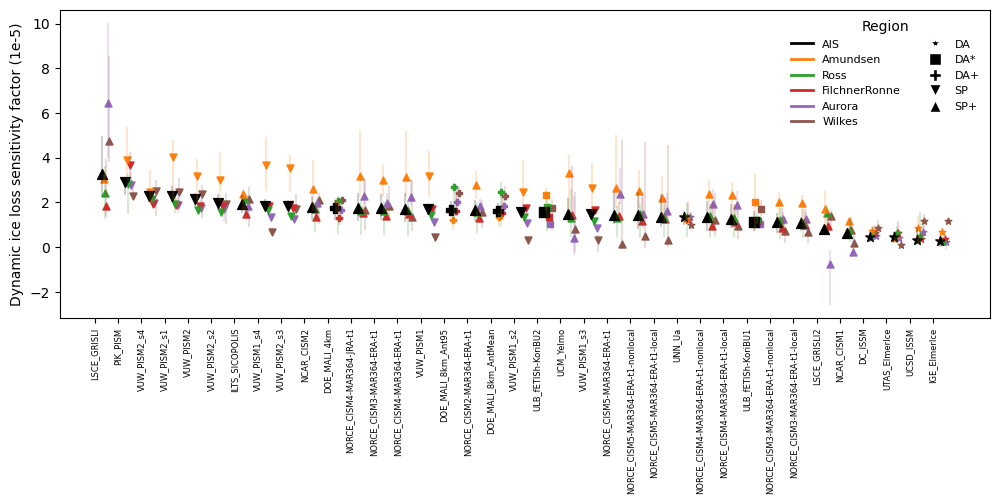

In [9]:
orderais = True
if orderais:
    index =np.argsort(df_best_new['dils_AIS'].values)
else:
    index =np.argsort(df_best_new['dils_Amundsen'].values)
index = index[::-1]
tappend = '_tmin2150'

#marker_key = 'calving'
marker_key = 'initialisation'
#marker_key = 'parameterization'
#marker_key = 'resolution'
marker_field_u = np.unique(df_best_new[marker_key])
#marker_u = ['^','*','s','P','v','p']
marker_u = ['*','s','P','v','^','p']
dic_marker = {}
for i,key in enumerate(marker_field_u):
    dic_marker[key]= marker_u[i]
markers = []
marker_nomodel=[]
msk = df_best_new.Model.values != 'VUW_PISM2_s1'

for key in df_best_new[marker_key][index]:
    markers.append(dic_marker[key])

for key in df_best_new[marker_key][msk]:
    marker_nomodel.append(dic_marker[key])

f,ax = plt.subplots(1,1,figsize =(12,4))
colors = ['black', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for i,region in enumerate(regions[::-1]):
    y = df_best_new[f'dils_{region}'].values[index]*1e5
    y_err_lower = df_best_new[f'dils_min_{region}'].values[index]*1e5
    y_err_upper = df_best_new[f'dils_max_{region}'].values[index]*1e5
    xall = np.arange(len(index)) * 8 + 5 - 0.5 * i
    
    for j, yl in enumerate(y_err_lower):
        yu = y_err_upper[j]
        ym = y[j]
        x=xall[j]
        if i == 5:
            plt.scatter(x, ym, marker=markers[j], color=colors[::-1][i], s=50)
        else:
            plt.scatter(x, ym, marker=markers[j], color=colors[::-1][i], s=25)
        plt.plot([x,x], [yl,yu], color=colors[::-1][i], alpha=0.2)
        
ax.set_xticks(np.arange(len(index))*8)
ax.set_xticklabels(df_best_new['Model'].values[index], rotation = 90,fontsize =6)
ax.set_ylabel('Dynamic ice loss sensitivity factor (1e-5)') ##TODO: Check units

# Legend for markers
marker_handles = [plt.Line2D([0], [0], marker=marker_u[i], color='w', 
                             markerfacecolor='k', markersize=8, 
                             label=marker_field_u[i]) 
                  for i in range(len(marker_field_u))]

# Legend for colors
color_handles = [plt.Line2D([0], [0], color=colors[i], lw=2, 
                            label=region) 
                 for i, region in enumerate(regions)]

# Combine marker and color legends into one
combined_handles = color_handles + marker_handles
combined_labels = regions + marker_field_u.tolist()

# Add the combined legend
ax.legend(handles=combined_handles, labels=combined_labels, title="Region", 
          loc='upper right', bbox_to_anchor=(1, 1), ncol=2, frameon=False, fontsize = 8)

# Save the figure with tight bounding box
if orderais:
    f.savefig(f'/Volumes/FMac/computing/data/antarctica/ismip6/hackathon/figures/dils_region_{marker_key}_AIS{tappend}.pdf', bbox_inches='tight')
    f.savefig(f'/Volumes/FMac/computing/data/antarctica/ismip6/hackathon/figures/dils_region_{marker_key}_AIS{tappend}.jpeg', bbox_inches='tight')
else:
    f.savefig(f'/Volumes/FMac/computing/data/antarctica/ismip6/hackathon/figures/dils_region_{marker_key}_Amundsen{tappend}.pdf', bbox_inches='tight')
    f.savefig(f'/Volumes/FMac/computing/data/antarctica/ismip6/hackathon/figures/dils_region_{marker_key}_Amundsen{tappend}.jpeg', bbox_inches='tight')

In [30]:
df_best_new = df_best.copy()
models = df_dils_prmse['Model'].unique()
for i,mod in enumerate(models):
    dfmodel = df_dils_prmse[df_dils_prmse['Model']==mod]
    mean_error = np.nanmean(dfmodel['AIS'])
    df_best_new.loc[df_best_new['Model'] == mod, 'mean-error'] = mean_error

In [36]:
regions

['AIS', 'Amundsen', 'Ross', 'FilchnerRonne', 'Aurora', 'Wilkes']

In [39]:
index = np.argsort(df_best_new['mean-error'].values)

for j,region in enumerate(regions):
    f,ax = plt.subplots(1,1,figsize =(12,4))
    ax2 = ax.twinx()
    ax.scatter(np.arange(len(index)),df_best_new['mean-error'].values[index],color = 'black')
    # for i in range(len(index)):
    #     ax.annotate(df_best['parameterization'].values[index][i],(i,df_best['mean-error'].values[index][i]),rotation = 90)
    
    ax.set_xticks(np.arange(len(index)))
    ax.set_xticklabels(df_best_new['Model'].values[index], rotation = 90)
    ax.set_ylabel('predictive mean  relative error (%)')
    ax2.scatter(np.arange(len(index)),df_best_new[f'dils_{region}'].values[index], color = 'red',alpha =  0.5)
     
    ax2.set_ylabel('Dynamic ice loss sensitivity',color = 'red')
    f.savefig(f'/Volumes/FMac/computing/data/antarctica/ismip6/hackathon/figures/dils_prmse_{region}{tappend}.pdf', bbox_inches='tight')
    plt.close()